In [116]:
#Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.interpolate import interp1d

## FEM Code

In [117]:
#A matrix from HW7
def A_matrix(n):
    step = n
    A = np.zeros((n-1,n-1))

    for i in range(n-1):
        A[i,i] = -2 * step
        if i > 0:
            A[i,i-1] = step
            
        if i < n-2:
            A[i,i+1] = step
    return A

In [118]:
# M matrix defined from hw 7
def M_matrix(n):
    step = 1/n
    count = n-1
    M = np.zeros((count,count))

    for i in range(count):
        M[i,i] = (4/6) * step
        if i>0:
            M[i,i-1] = (1/6) * step
        if i< count -1:
            M[i,i+1] = (1/6) * step
    return M

In [119]:
def u_vec(a, b, n, pluck_distance, pull_length):
    x = np.linspace(a, b, n+1)[1:-1]
    u = np.where(x <= pluck_distance,
                 (pull_length * x) / pluck_distance,
                 (pull_length * (b - x)) / (b - pluck_distance))
    return u

In [120]:
#solver function
def fem_solve(a,b,n,pluck_distance, pull_length, t, dt, density, area, tension_0, c_d):
    #main matrix defs
    A_mat = A_matrix(n)
    M = M_matrix(n)
    M_inv = np.linalg.inv(M)

    #initial cond
    u = u_vec(a,b,n,pluck_distance, pull_length)
    v = np.zeros(n-1)

    #solver
    times = np.arange(0,t,dt)
    history = ([u.copy()])

    #speed booster hehe
    left = (tension_0/(density*area))*M_inv@ A_mat
    right = c_d/(density*area)

    for t in times:
        #first slope step
        step1u = v
        step1v = left@u-right*v

        #second step
        step2u = v + 0.5 * dt * step1v
        step2v = left@(u + 0.5 * dt *step1u)-right*(v+0.5*dt*step1v)

        #step 3
        step3u = v + 0.5 * dt * step2v
        step3v = left@(u + 0.5 * dt *step2u)-right*(v+0.5*dt*step2v)

        #step 4
        step4u = v + dt * step3v
        step4v = left@(u + dt *step3u)-right*(v+dt*step3v)

        #weighted average of all four
        u = u + (dt/6)*(step1u + 2 * step2u + 2*step3u + step4u)
        v = v + (dt/6)*(step1v + 2 * step2v + 2 * step3v + step4v)

        #append and loop this sucker again
        history.append(u.copy())

    return np.array(history), times

## Analytical Solution Code

In [121]:
#analytical solver
def analytical_solution(x, t, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier):
    u = np.zeros_like(x)
    L = b-a
    c = np.sqrt(tension_0/(density*area))
    for n in range(1,num_fourier+1):
        Bn = ((2*L**2*pull_l)/(n**2 * np.pi**2 * pluck_d * (L - pluck_d)))*np.sin((n * np.pi * pluck_d )/ L)
        sum_entry = Bn * np.sin((n*np.pi*x)/L)*np.cos((n*np.pi*c*t)/L)*np.exp(-c_d*t/(2*density*area))
        u += sum_entry
    return u


## Solving Conditions

In [122]:
## Solving
a = 0
b = 1
density = 10000
area = 5*10**(-7)
tension_0 = 80
c = np.sqrt(tension_0/(density*area))
n = 100
dx = (b-a)/n
dt = 0.4 * (dx/c)
L = b-a
period = 6
t = (period*L)/c
c_d = 0.3
pluck_d = 0.8
pull_l = 0.002
num_fourier = 10000

#FEM solver
history, times = fem_solve(a,b,n,pluck_d, pull_l, t, dt, density, area, tension_0, c_d)

#analytical solver
x = np.linspace(a, b, n+1)
x_analytical = np.linspace(a, b, 101)
u_analytical = analytical_solution(x, t, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier = 10000)

In [129]:
#Expirement 1, chaning

#fundemental frequency
from scipy.signal import find_peaks

# fundamental frequency experiment - vary string length
b_vals = [0.5, 1.0, 2.0]

for b in b_vals:
    L = b - a
    c = np.sqrt(tension_0/(density*area))
    dx = L/n
    dt = 0.4*(dx/c)
    t = (6*L)/c  # 6 periods

    f_theoretical = c/(2*L)

    history, times = fem_solve(a, b, n, pluck_d, pull_l, t, dt, density, area, tension_0, c_d)

    # midpoint displacement over time
    mid = history.shape[1] // 2
    u_mid = history[:, mid]

    # find peaks
    # only find peaks above 10% of max amplitude
    peaks, _ = find_peaks(u_mid, height=0.1*np.max(u_mid), distance=int(0.5/(f_theoretical*dt)))

    if len(peaks) >= 2:
        period = times[peaks[1]] - times[peaks[0]]
        f_numerical = 1/period
        print(f"b={b}m: Theoretical={f_theoretical:.2f} Hz, Numerical={f_numerical:.2f} Hz, Error={abs(f_theoretical-f_numerical)/f_theoretical*100:.2f}%")
    else:
        print(f"b={b}m: not enough peaks found")



b=0.5m: Theoretical=126.49 Hz, Numerical=92.33 Hz, Error=27.01%
b=1.0m: Theoretical=63.25 Hz, Numerical=63.76 Hz, Error=0.81%
b=2.0m: Theoretical=31.62 Hz, Numerical=31.88 Hz, Error=0.81%


In [ ]:
#Expirament 2 tension and stiffness

## Checking Initial Condition
Do they match?

Text(0, 0.5, 'Displacement (m)')

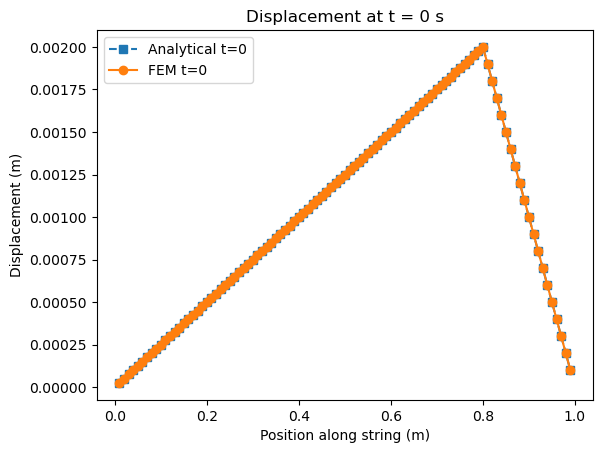

In [123]:
#initial plot overlay
t0 = 0.0
x_fem = np.linspace(a, b, n+1)[1:-1]
u_fem0 = history[0]
u_analytical0 = analytical_solution(x_fem, t0, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier)

#plotting
plt.plot(x_fem, u_analytical0, 's--', label='Analytical t=0')
plt.plot(x_fem, u_fem0, 'o-', label='FEM t=0')
plt.legend()
plt.title('Displacement at t = 0 s'.format(t))
plt.xlabel('Position along string (m)')
plt.ylabel('Displacement (m)')  

## Animation

In [124]:
#animation plot FEM
# def plot_gif(history, dt, n, filename='wave.gif'):
#     x = np.linspace(0, 1, n+1)[1:-1]  
    
#     print(f'x shape: {x.shape}')
#     print(f'history[0] shape: {history[0].shape}')
    
#     fig, ax = plt.subplots()
#     line, = ax.plot(x, history[0])
#     ax.set_ylim(-0.005, 0.005)
#     ax.set_xlim(0, 1)
#     ax.set_xlabel('x')
#     ax.set_ylabel('u')
    
#     frames = history[::2]
    
#     def update(i):
#         line.set_ydata(frames[i])
#         ax.set_title(f'frame {i}')
#         return line,
    
#     ani = animation.FuncAnimation(
#         fig, update,
#         frames=len(frames),
#         interval=50
#     )
    
#     ani.save(filename, writer='pillow', fps=30)
#     plt.close()
#     print(f'saved to {filename}')

# n_actual = history[0].shape[0] + 1
# plot_gif(history, dt, n_actual)


In [125]:
#animation for analytical solution
def plot_analytical_gif(dt, density, area, tension_0, c_d, a, b, pull_l, pluck_d, num_fourier, filename='analytical.gif'):
    x_fine = np.linspace(a, b, 400)
    t_end = (10*(b-a))/np.sqrt(tension_0/(density*area))
    times = np.arange(0, t_end, dt)
    frames = times[::2]

    fig, ax = plt.subplots(figsize=(9, 4))
    u0 = analytical_solution(x_fine, 0, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier)
    line, = ax.plot(x_fine, u0, 'r-', lw=2)
    ax.axhline(0, color='b', lw=0.5, ls='--', alpha=0.3)
    ax.set_xlim(a, b)
    ax.set_ylim(-pull_l*1.5, pull_l*1.5)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('u (m)')
    ax.grid(True, alpha=0.3)

    def update(i):
        t_val = frames[i]
        u = analytical_solution(x_fine, t_val, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier)
        line.set_ydata(u)
        ax.set_title(f'Analytical  —  t = {t_val*1000:.1f} ms ')
        return line,

    ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=20)
    ani.save(filename, writer='pillow', fps=50)
    plt.close()
    print(f'saved to {filename}')

plot_analytical_gif(dt, density, area, tension_0, c_d, a, b, pull_l, pluck_d, num_fourier=100)

saved to analytical.gif


## Convergence

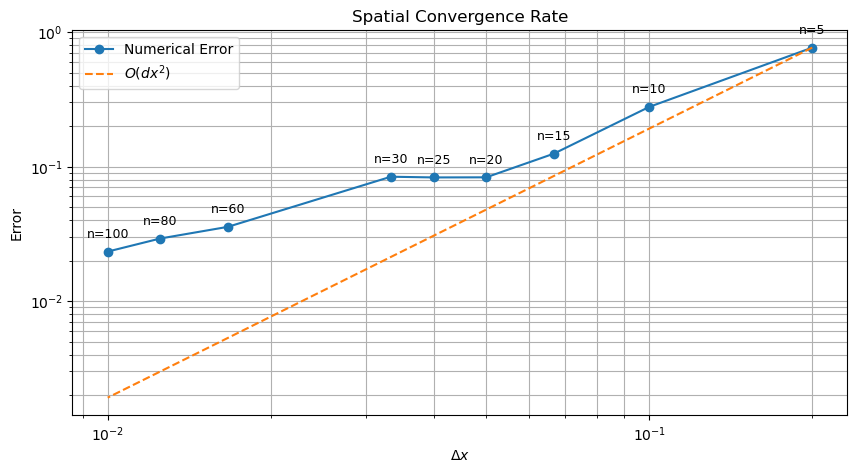

In [126]:
# SPATIAL CONVERGENCE TEST
period = 6
t_f = (period*L)/c
eval_pt = 1
t_eval = eval_pt * t_f  # eval at some point 

dt = 1e-7 # small dt to minimize temporal error
n_vals = [5, 10, 15, 20, 25, 30,60,80,100]
spatial_errors = []

for n in n_vals:
    history, times = fem_solve(a, b, n, pluck_d, pull_l, t_f, dt, density, area, tension_0, c_d)
    
    t_actual = times[-1]  # Use actual final time
    
    u_fem = history[-1]
    
    x = np.linspace(0, L, n+1)[1:-1]
    u_true = analytical_solution(x, t_actual, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier)
    
    spatial_error = np.linalg.norm(u_fem - u_true) / np.linalg.norm(u_true)
    spatial_errors.append(spatial_error)

# plot
dx_values = [L/n for n in n_vals]
plt.figure(figsize=(10, 5))
plt.loglog(dx_values, spatial_errors, '-o', label='Numerical Error')
plt.loglog(dx_values, [dx**2 * (spatial_errors[0]/dx_values[0]**2) for dx in dx_values], '--', label='$O(dx^2)$')
plt.xlabel('$\Delta x$')
plt.ylabel('Error')
plt.title('Spatial Convergence Rate')
plt.legend()
plt.grid(True, which="both", ls="-")
for i, n in enumerate(n_vals):
    plt.annotate(f'n={n}', xy=(dx_values[i], spatial_errors[i]),textcoords="offset points", ha='center',xytext=(0, 10),fontsize=9)

plt.show()

CFL limit: 3.16e-06


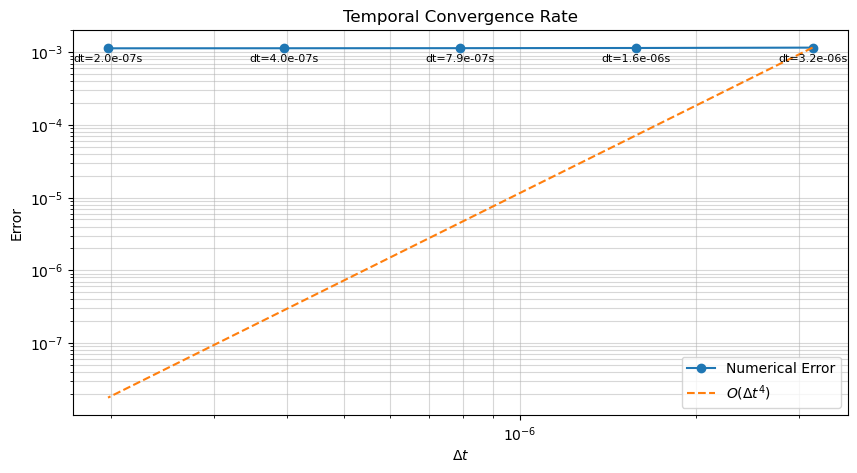

In [127]:
# TEMPORAL CONVERGENCE TEST
period = 1
t_f = (period*L)/c

num_fourier = 10000 # want to be high to isolate temporal error rn

n_fixed =  1000 # large n to minimize spatial error
dt_cfl = 0.4 * (1/n_fixed) / c
print(f"CFL limit: {dt_cfl:.2e}")

dt_vals = [dt_cfl, dt_cfl/2, dt_cfl/4, dt_cfl/8, dt_cfl/16]
temporal_errors = []

for dt in dt_vals:
    history, times = fem_solve(a, b, n_fixed, pluck_d, pull_l, t_f, dt, density, area, tension_0, c_d)
    
    t_actual = times[-1]

    u_fem = history[-1] # disp at t_f
    
    x = np.linspace(0, L, n_fixed+1)[1:-1]
    u_true = analytical_solution(x, t_actual, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier)
    
    err = np.linalg.norm(u_fem - u_true) / np.linalg.norm(u_true)
    temporal_errors.append(err)

# plot
plt.figure(figsize=(10, 5))
plt.loglog(dt_vals, temporal_errors, '-o', label='Numerical Error')
plt.loglog(dt_vals, [dt**4 * (temporal_errors[0] / dt_vals[0]**4) for dt in dt_vals], '--', label='$O(\Delta t^4)$')
plt.xlabel('$\Delta t$')
plt.ylabel('Error')
plt.title('Temporal Convergence Rate')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
for i, dt in enumerate(dt_vals):
    plt.annotate(f'dt={dt:.1e}s', 
                 xy=(dt_vals[i], temporal_errors[i]),
                 textcoords="offset points", 
                 xytext=(0, -10), 
                 ha='center', 
                 fontsize=8)

plt.show()